# Problema 1 – Clasificación: Detección de Fatiga Muscular en Ciclismo
**Universidad EAFIT – Introducción a la Inteligencia Artificial (2026-01)**

---

## Descripción
Clasificación binaria sobre señales EMG de 8 músculos de la pierna dominante para detectar fatiga muscular en ciclistas.

- **Dataset:** [YominE/Muscle_Fatigue_Cycling](https://huggingface.co/datasets/YominE/Muscle_Fatigue_Cycling)
- **Frecuencia de muestreo:** 1000 Hz (paso de 0.001 s)
- **Total de muestras:** 3,002,137
- **Target binario:**
  - `0` = Condición normal (original: 0 – No Fatiga)
  - `1` = Desgaste muscular (originales: 1 – Transición a Fatiga, 2 – Fatiga)

## 0. Instalación de dependencias

In [17]:
!pip install datasets huggingface_hub scikit-learn pandas numpy matplotlib seaborn scipy tensorflow -q

## 1. Carga del Dataset

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Cargando dataset desde HuggingFace...')
dataset = load_dataset('YominE/Muscle_Fatigue_Cycling')
df = pd.DataFrame(dataset['train'])

print(f'Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
df.head()

Cargando dataset desde HuggingFace...
Shape: (3002137, 10)
Columnas: ['Time', 'Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis', 'Target']


,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0


## 1a. Análisis Preliminar del Problema

### Preprocesamiento del target

El dataset tiene 3 etiquetas originales:
- `0` → No Fatiga
- `1` → Transición a Fatiga  
- `2` → Fatiga

Se binariza según la instrucción del taller (`2 → 1`), quedando:
- `0` = Condición normal
- `1` = Desgaste muscular

**Justificación:** El dataset recomienda explícitamente la clasificación binaria porque la clase Fatiga (2) tiene muy pocos datos. Además, clínicamente es más relevante detectar el **inicio del desgaste** para intervenir a tiempo.

In [19]:
# Nombres exactos de las columnas del dataset
FS         = 1000   # Frecuencia de muestreo: 1000 Hz
TIME_COL   = 'Time'
TARGET_COL = 'Target'

EMG_COLS = [
    'Right Rectus femoris',
    'Left Gluteus maximus',
    'Left Gastrocnemius medialis',
    'Left Semitendinosus',
    'Left Biceps femoris caput longus',
    'Right Vastus medialis',
    'Right Tibialis anterior',
    'Left Gastrocnemius lateralis'
]

print('Distribución original del target:')
vc = df[TARGET_COL].value_counts().sort_index()
print(f'  0 (No Fatiga):           {vc.get(0, 0):>8,}')
print(f'  1 (Transición a Fatiga): {vc.get(1, 0):>8,}')
print(f'  2 (Fatiga):              {vc.get(2, 0):>8,}')

# Binarización: 2 → 1
df['target_binary'] = df[TARGET_COL].apply(lambda x: 0 if x == 0 else 1)

vc2 = df['target_binary'].value_counts().sort_index()
print('\nDistribución binaria:')
print(f'  0 (Normal):  {vc2.get(0, 0):>8,}')
print(f'  1 (Fatiga):  {vc2.get(1, 0):>8,}')

Distribución original del target:
  0 (No Fatiga):           2,127,600
  1 (Transición a Fatiga):  631,200
  2 (Fatiga):               243,337

Distribución binaria:
  0 (Normal):  2,127,600
  1 (Fatiga):   874,537


### 1b. Clasificación de características

| Columna | Tipo | Descripción |
|---|---|---|
| `Time` | Numérica continua | Tiempo en segundos (resolución 0.001 s) |
| `Right Rectus femoris` | Numérica continua (mV) | EMG del Recto femoral derecho |
| `Left Gluteus maximus` | Numérica continua (mV) | EMG del Glúteo mayor izquierdo |
| `Left Gastrocnemius medialis` | Numérica continua (mV) | EMG del Gastrocnemio medial izquierdo |
| `Left Semitendinosus` | Numérica continua (mV) | EMG del Semitendinoso izquierdo |
| `Left Biceps femoris caput longus` | Numérica continua (mV) | EMG del Bíceps femoral largo izquierdo |
| `Right Vastus medialis` | Numérica continua (mV) | EMG del Vasto medial derecho |
| `Right Tibialis anterior` | Numérica continua (mV) | EMG del Tibial anterior derecho |
| `Left Gastrocnemius lateralis` | Numérica continua (mV) | EMG del Gastrocnemio lateral izquierdo |
| `Target` | Categórica ordinal → binaria | Estado muscular del sujeto |

In [20]:
print('Estadísticas descriptivas de los 8 canales EMG:')
df[EMG_COLS].describe().round(5)

Estadísticas descriptivas de los 8 canales EMG:


,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis
count,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06
mean,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00
std,4.323000e-02,2.126000e-02,4.680000e-02,3.235000e-02,4.256000e-02,7.176000e-02,5.702000e-02,5.927000e-02
min,-8.433400e-01,-1.117290e+00,-1.749320e+00,-1.575970e+00,-7.503000e-01,-1.216620e+00,-1.304430e+00,-1.199720e+00
25%,-9.710000e-03,-3.880000e-03,-8.920000e-03,-6.290000e-03,-8.240000e-03,-9.510000e-03,-1.333000e-02,-1.392000e-02
50%,4.000000e-05,-1.000000e-05,1.000000e-04,-1.300000e-04,1.600000e-04,1.200000e-04,-1.500000e-04,6.500000e-04
75%,1.019000e-02,3.920000e-03,9.310000e-03,6.090000e-03,9.010000e-03,1.113000e-02,1.316000e-02,1.687000e-02
max,9.920800e-01,1.063230e+00,1.614780e+00,8.685900e-01,8.429900e-01,1.079530e+00,1.336620e+00,9.400500e-01


## 3a. EDA – Visualización de señales en el tiempo

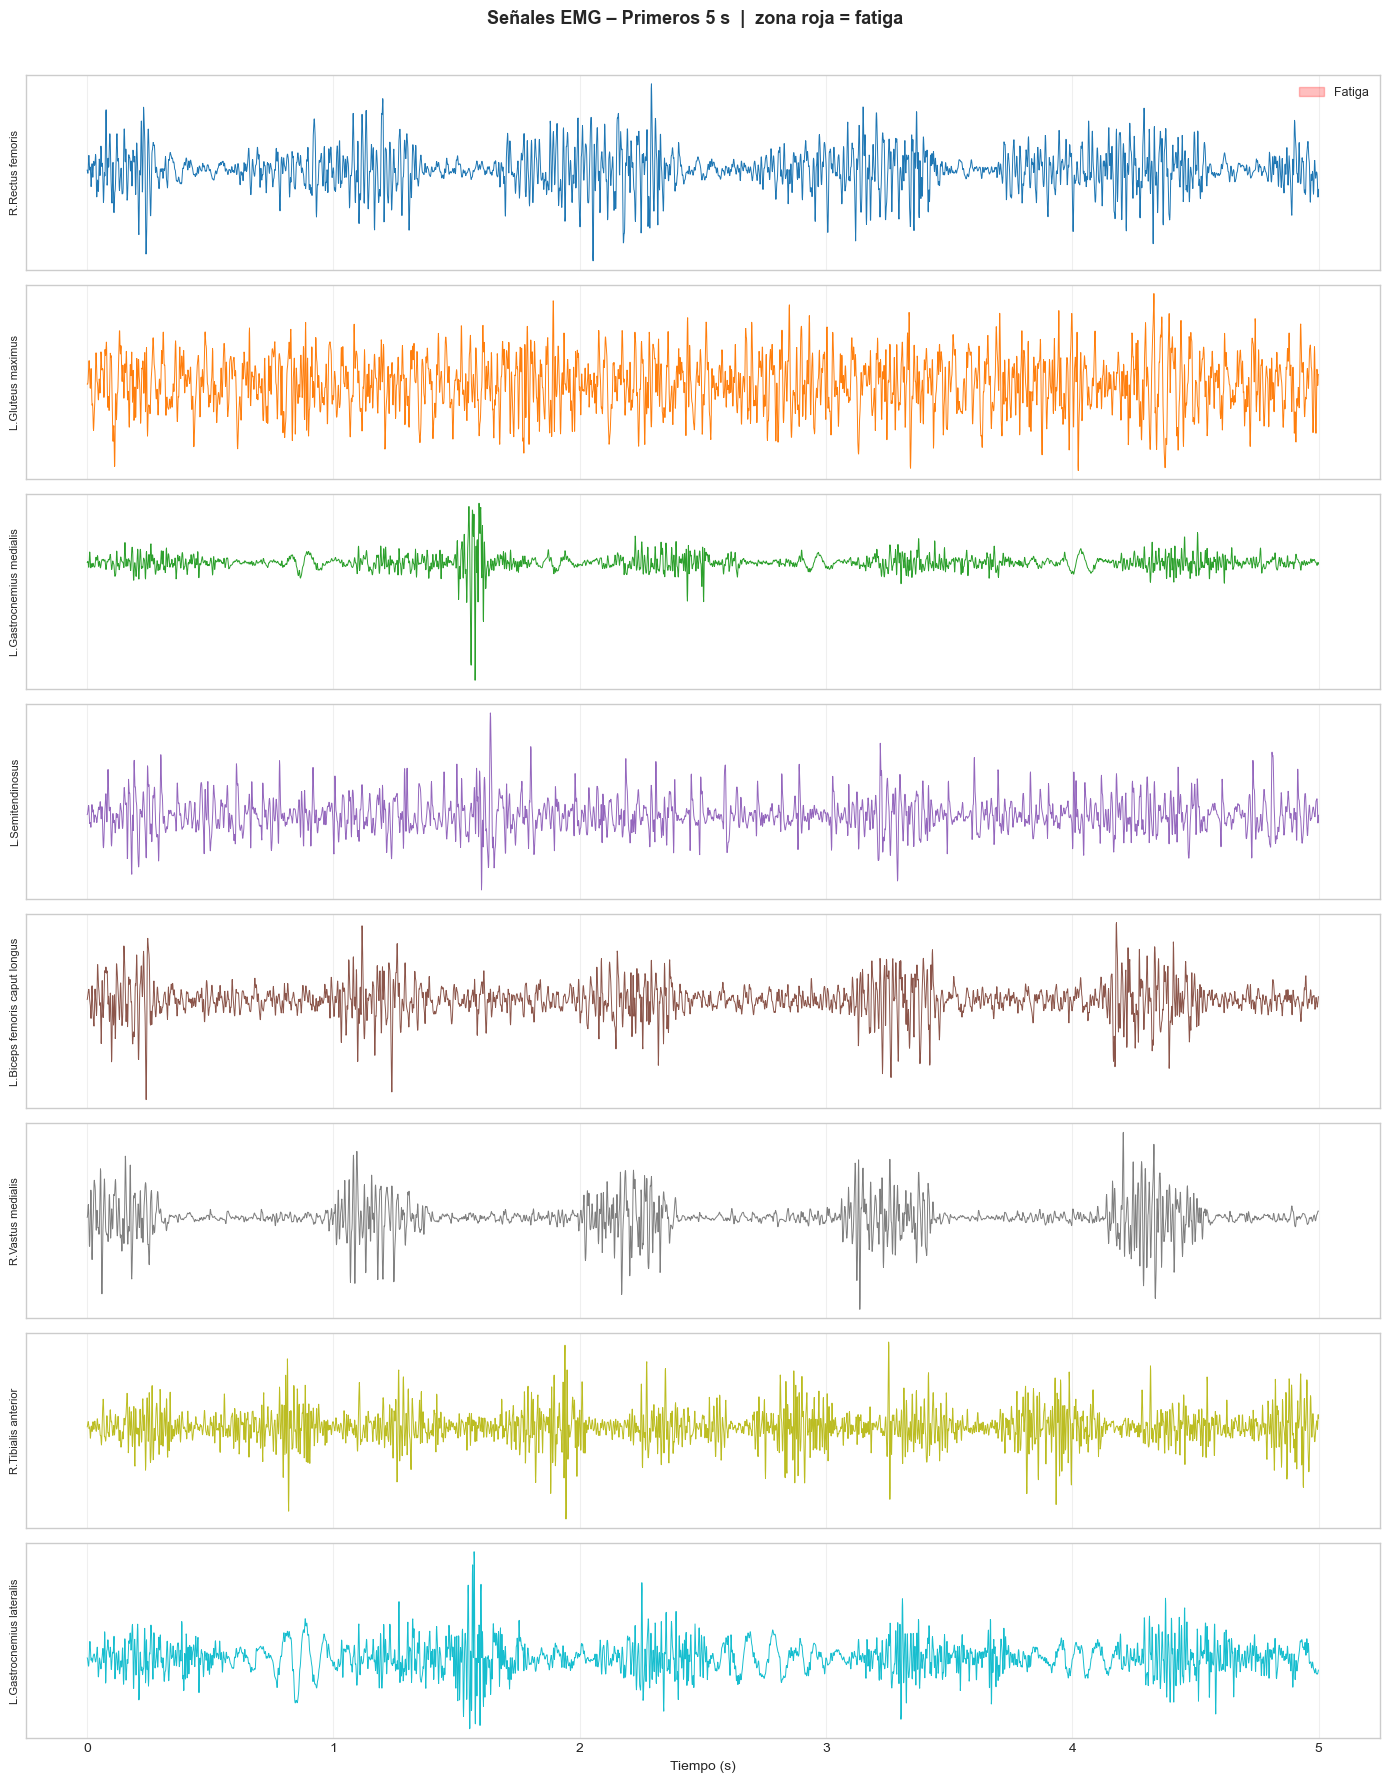


[Conclusiones sobre el dataset]
- Señales EMG con amplitudes en el rango ±0.2 mV aproximadamente.
- Frecuencia de muestreo de 1000 Hz: adecuada para capturar dinámica EMG (Nyquist a 500 Hz).
- El dataset presenta marcado desbalance: la clase fatiga representa una fracción pequeña.
- Se observan cambios de amplitud y frecuencia en las zonas de fatiga (zona roja).
- La variable Time tiene dependencia lineal con el target → se excluye del modelado.


In [21]:
# Graficar primeros 5 segundos = 5000 muestras @ 1000 Hz
N_PLOT = 5000
x_axis    = df[TIME_COL].values[:N_PLOT]
labels_seg = df['target_binary'].values[:N_PLOT]
colors     = plt.cm.tab10(np.linspace(0, 1, len(EMG_COLS)))

fig, axes = plt.subplots(len(EMG_COLS), 1, figsize=(14, 2.2*len(EMG_COLS)), sharex=True)

for i, (col, ax) in enumerate(zip(EMG_COLS, axes)):
    signal = df[col].values[:N_PLOT]
    ax.plot(x_axis, signal, color=colors[i], linewidth=0.7)
    ax.fill_between(x_axis, signal.min(), signal.max(),
                    where=(labels_seg == 1), alpha=0.25, color='red', label='Fatiga')
    ax.set_ylabel(col.replace('Left ', 'L.').replace('Right ', 'R.'), fontsize=8)
    ax.set_yticks([]); ax.grid(True, alpha=0.3)

axes[0].legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel('Tiempo (s)')
fig.suptitle('Señales EMG – Primeros 5 s  |  zona roja = fatiga', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('emg_signals.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n[Conclusiones sobre el dataset]')
print('- Señales EMG con amplitudes en el rango ±0.2 mV aproximadamente.')
print('- Frecuencia de muestreo de 1000 Hz: adecuada para capturar dinámica EMG (Nyquist a 500 Hz).')
print('- El dataset presenta marcado desbalance: la clase fatiga representa una fracción pequeña.')
print('- Se observan cambios de amplitud y frecuencia en las zonas de fatiga (zona roja).')
print('- La variable Time tiene dependencia lineal con el target → se excluye del modelado.')

## 2. Feature Engineering – Extracción de Características por Ventanas de 1 Segundo

Con fs = 1000 Hz y ventana de 1 s → **1000 muestras por ventana** → ~3002 ventanas totales.

---

### ¿Por qué usar ventanas?

El dataset original tiene **3,002,137 filas** (una por cada milisegundo). Un solo instante aislado no dice nada sobre la fatiga; la fatiga se revela en el **comportamiento de la señal a lo largo del tiempo**. La solución es agrupar las filas en **ventanas de 1 segundo** y resumir cada ventana con unas pocas características.

```
Señal original (cada guión es una muestra @ 1000 Hz):

|---...---||---...---||---...---||---...---|
 Ventana 1   Ventana 2   Ventana 3   Ventana 4
 (1000 ms)   (1000 ms)   (1000 ms)   (1000 ms)
```

Las ventanas **no se solapan** (sin overlapping): cuando termina una, empieza la siguiente. El resultado es una tabla ~1000 veces más pequeña:

```
Dataset original  →  3,002,137 filas × 10 columnas
          ↓   (ventanas de 1000 muestras + 8 features/canal)
Nuevo dataset     →        ~3002 filas × 65 columnas
```

> **Nota:** La columna `Time` **no se incluye** en el nuevo dataset. El tiempo aumenta linealmente con el target (a más tiempo → más fatiga), lo que haría que el modelo «hiciera trampa» en lugar de aprender de las señales EMG reales.

---

### Justificación de las 8 características

| # | Nombre | Dominio | Justificación |
|---|---|---|---|
| 1 | **RMS** | Tiempo | Mide la potencia de activación muscular. Aumenta con fatiga por reclutamiento extra de unidades motoras |
| 2 | **Varianza** | Tiempo | Captura dispersión de la señal. Refleja irregularidad en el patrón neuromotor con la fatiga |
| 3 | **Zero Crossing Rate** | Tiempo | Tasa de cruces por cero. Relacionada con la frecuencia; disminuye con fatiga |
| 4 | **Mean Absolute Value** | Tiempo | Indicador clásico de intensidad de contracción muscular |
| 5 | **Waveform Length** | Tiempo | Longitud acumulada de la onda. Refleja complejidad y variabilidad de la señal |
| 6 | **Frecuencia Mediana** | Frecuencia | El espectro EMG se desplaza a bajas frecuencias con la fatiga (indicador fisiológico clásico) |
| 7 | **Frecuencia Media** | Frecuencia | Centroide espectral. Muy sensible a cambios por fatiga |
| 8 | **Potencia Espectral Total** | Frecuencia | Energía total del espectro. Aumenta con mayor activación muscular |


In [22]:
from scipy.signal import welch

def extract_features_window(window, fs=1000):
    """
    Extrae 8 características de una ventana EMG de 1 segundo.

    Dominio del tiempo : RMS, Varianza, ZCR, MAV, Waveform Length
    Dominio frecuencia : Frec. mediana, Frec. media, Potencia total
    (Método espectral: scipy.signal.welch — más robusto al ruido que la FFT directa)
    """
    window = np.asarray(window, dtype=float)

    # ── Dominio del tiempo ──
    rms      = np.sqrt(np.mean(window**2))
    variance = np.var(window)
    zcr      = np.sum(np.diff(np.sign(window)) != 0) / len(window)
    mav      = np.mean(np.abs(window))
    wl       = np.sum(np.abs(np.diff(window)))

    # ── Dominio de la frecuencia (Welch PSD) ──
    freqs, psd = welch(window, fs=fs)
    total_power = np.sum(psd)

    if total_power > 0:
        mean_freq    = np.sum(freqs * psd) / total_power
        cum_psd      = np.cumsum(psd)
        mid_idx      = np.searchsorted(cum_psd, cum_psd[-1] / 2)
        median_freq  = freqs[min(mid_idx, len(freqs) - 1)]
    else:
        mean_freq = median_freq = 0.0

    return {
        'rms': rms, 'variance': variance, 'zcr': zcr,
        'mav': mav, 'wl': wl,
        'median_freq': median_freq, 'mean_freq': mean_freq,
        'total_power': total_power
    }

# Prueba rápida en la primera ventana
test_feats = extract_features_window(df[EMG_COLS[0]].values[:1000], fs=FS)
print(f'Características extraídas ({EMG_COLS[0]}, primera ventana):')
for k, v in test_feats.items():
    print(f'  {k:15s}: {v:.6f}')


Características extraídas (Right Rectus femoris, primera ventana):
  rms            : 0.011706
  variance       : 0.000137
  zcr            : 0.123000
  mav            : 0.008125
  wl             : 3.072632
  median_freq    : 50.781250
  mean_freq      : 54.570839
  total_power    : 0.000037


In [23]:
def create_feature_dataset(df, emg_cols, target_col, fs=1000, window_seconds=1.0):
    """
    Construye el nuevo dataset de características siguiendo el tutorial:
    - Ventanas no solapadas de 1 s (1000 muestras @ 1 kHz)
    - 8 características por canal (4 tiempo + 3 frecuencia)
    - Target por mayoría de votos dentro de la ventana
    - Columna Time excluida (correlación directa con target → data leakage)
    """
    window_size = int(fs * window_seconds)   # 1000 muestras
    n_windows   = len(df) // window_size

    print(f'Tamaño de ventana : {window_size} muestras = {window_seconds} s @ {fs} Hz')
    print(f'Total de muestras : {len(df):,}')
    print(f'Ventanas completas: {n_windows:,}')
    print(f'Factor de reducción: {len(df) / n_windows:.0f}× (de {len(df):,} filas a {n_windows:,})')

    rows = []
    for i in range(n_windows):
        start     = i * window_size
        end       = start + window_size
        window_df = df.iloc[start:end]

        row = {}
        for ch in emg_cols:
            sig   = window_df[ch].values.astype(float)
            feats = extract_features_window(sig, fs=fs)
            # Nombre abreviado: 'Right Rectus femoris' → 'R_Rectus_femoris'
            short = (ch.replace('Right ', 'R_').replace('Left ', 'L_')
                       .replace(' ', '_').replace('caput_longus', 'cl'))
            for fname, fval in feats.items():
                row[f'{short}_{fname}'] = fval

        # Target: etiqueta más frecuente dentro de la ventana
        row['target'] = int(window_df[target_col].mode()[0])
        rows.append(row)

        if (i + 1) % 500 == 0:
            print(f'  Procesadas {i+1}/{n_windows} ventanas...')

    feat_df = pd.DataFrame(rows)
    n_feat = feat_df.shape[1] - 1  # sin contar 'target'
    print(f'\n✓ Dataset listo: {feat_df.shape[0]} ventanas × {n_feat} features')
    print(f'  ({len(emg_cols)} músculos × {n_feat // len(emg_cols)} características/músculo)')
    return feat_df

feat_df = create_feature_dataset(df, EMG_COLS, 'target_binary', fs=FS)
feat_df.head()


Tamaño de ventana : 1000 muestras = 1.0 s @ 1000 Hz
Total de muestras : 3,002,137
Ventanas completas: 3,002
Factor de reducción: 1000× (de 3,002,137 filas a 3,002)
  Procesadas 500/3002 ventanas...
  Procesadas 1000/3002 ventanas...
  Procesadas 1500/3002 ventanas...
  Procesadas 2000/3002 ventanas...
  Procesadas 2500/3002 ventanas...
  Procesadas 3000/3002 ventanas...

✓ Dataset listo: 3002 ventanas × 64 features
  (8 músculos × 8 características/músculo)


,R_Rectus_femoris_rms,R_Rectus_femoris_variance,R_Rectus_femoris_zcr,R_Rectus_femoris_mav,R_Rectus_femoris_wl,R_Rectus_femoris_median_freq,R_Rectus_femoris_mean_freq,R_Rectus_femoris_total_power,L_Gluteus_maximus_rms,L_Gluteus_maximus_variance,...,R_Tibialis_anterior_total_power,L_Gastrocnemius_lateralis_rms,L_Gastrocnemius_lateralis_variance,L_Gastrocnemius_lateralis_zcr,L_Gastrocnemius_lateralis_mav,L_Gastrocnemius_lateralis_wl,L_Gastrocnemius_lateralis_median_freq,L_Gastrocnemius_lateralis_mean_freq,L_Gastrocnemius_lateralis_total_power,target
0,0.011706,0.000137,0.123,0.008125,3.072632,50.78125,54.570839,0.000037,0.003989,0.000016,...,0.000134,0.025655,0.000658,0.120,0.019441,6.501237,50.78125,59.538860,0.000127,0
1,0.014023,0.000197,0.111,0.010118,3.886684,54.68750,55.855995,0.000045,0.004223,0.000018,...,0.000127,0.031409,0.000986,0.149,0.021678,11.258436,78.12500,79.432906,0.000294,0
2,0.014820,0.000220,0.121,0.010151,3.836192,46.87500,54.184637,0.000051,0.004209,0.000018,...,0.000115,0.026209,0.000687,0.101,0.020389,7.276616,54.68750,58.352164,0.000219,0
3,0.013817,0.000191,0.121,0.009894,3.911660,46.87500,57.536178,0.000053,0.004374,0.000019,...,0.000144,0.021673,0.000470,0.154,0.015846,7.979359,93.75000,86.660433,0.000133,0
4,0.013326,0.000177,0.122,0.009676,4.037879,46.87500,58.618736,0.000045,0.004641,0.000022,...,0.000087,0.025220,0.000636,0.138,0.019283,8.701242,78.12500,76.983962,0.000181,0


In [24]:
feat_df.describe().round(5)

,R_Rectus_femoris_rms,R_Rectus_femoris_variance,R_Rectus_femoris_zcr,R_Rectus_femoris_mav,R_Rectus_femoris_wl,R_Rectus_femoris_median_freq,R_Rectus_femoris_mean_freq,R_Rectus_femoris_total_power,L_Gluteus_maximus_rms,L_Gluteus_maximus_variance,...,R_Tibialis_anterior_total_power,L_Gastrocnemius_lateralis_rms,L_Gastrocnemius_lateralis_variance,L_Gastrocnemius_lateralis_zcr,L_Gastrocnemius_lateralis_mav,L_Gastrocnemius_lateralis_wl,L_Gastrocnemius_lateralis_median_freq,L_Gastrocnemius_lateralis_mean_freq,L_Gastrocnemius_lateralis_total_power,target
count,3002.00000,3002.00000,3002.00000,3002.00000,3002.00000,3002.00000,3002.00000,3002.00000,3002.00000,3002.00000,...,3002.00000,3002.00000,3002.00000,3002.00000,3002.00000,3002.00000,3002.00000,3002.00000,3002.00000,3002.00000
mean,0.03570,0.00187,0.10887,0.02260,8.16890,47.49308,54.01574,0.00048,0.01171,0.00045,...,0.00083,0.05113,0.00351,0.13670,0.03377,15.48634,65.93000,71.12226,0.00090,0.29114
std,0.02438,0.00361,0.01309,0.01526,5.47515,8.36863,6.26414,0.00098,0.01775,0.00246,...,0.00200,0.02998,0.00439,0.02151,0.02143,9.38721,16.92998,12.39891,0.00115,0.45436
min,0.00297,0.00001,0.06300,0.00224,0.92528,15.62500,20.48709,0.00000,0.00280,0.00001,...,0.00000,0.00288,0.00001,0.06600,0.00203,1.05426,11.71875,26.34509,0.00000,0.00000
25%,0.02157,0.00047,0.10000,0.01346,5.01826,42.96875,50.66033,0.00010,0.00536,0.00003,...,0.00012,0.02931,0.00086,0.12400,0.01916,9.10669,62.50000,67.00702,0.00021,0.00000
50%,0.02974,0.00088,0.10900,0.01852,6.82545,46.87500,54.55581,0.00022,0.00702,0.00005,...,0.00023,0.04321,0.00187,0.13400,0.02759,12.96090,66.40625,72.36429,0.00048,0.00000
75%,0.04217,0.00178,0.11800,0.02694,9.55237,50.78125,58.06711,0.00044,0.01089,0.00012,...,0.00054,0.06651,0.00442,0.14800,0.04384,20.23903,74.21875,77.92716,0.00112,1.00000
max,0.19068,0.03636,0.15500,0.12844,45.73347,74.21875,71.69424,0.01150,0.19643,0.03858,...,0.02299,0.19016,0.03615,0.21400,0.14763,78.35691,125.00000,113.79971,0.00966,1.00000


## 3. Análisis Exploratorio de Datos (EDA)

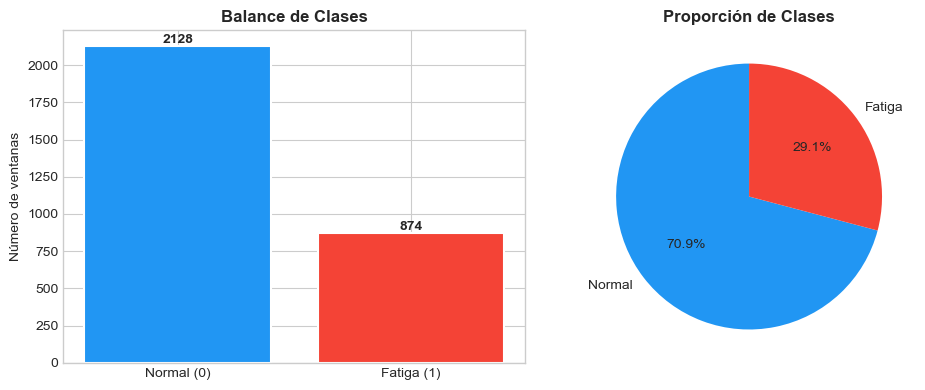

Ratio de desbalance: 0.411
⚠ Desbalance detectado → se usará class_weight="balanced" en los modelos.


In [25]:
# ── Balance de clases ──
counts = feat_df['target'].value_counts().sort_index()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(['Normal (0)', 'Fatiga (1)'], counts.values,
        color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)
ax1.set_title('Balance de Clases', fontweight='bold')
ax1.set_ylabel('Número de ventanas')
for i, v in enumerate(counts.values):
    ax1.text(i, v + max(counts)*0.01, str(v), ha='center', fontweight='bold')

ax2.pie(counts.values, labels=['Normal', 'Fatiga'], autopct='%1.1f%%',
        colors=['#2196F3', '#F44336'], startangle=90)
ax2.set_title('Proporción de Clases', fontweight='bold')
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = counts.min() / counts.max()
print(f'Ratio de desbalance: {ratio:.3f}')
if ratio < 0.8:
    print('⚠ Desbalance detectado → se usará class_weight="balanced" en los modelos.')

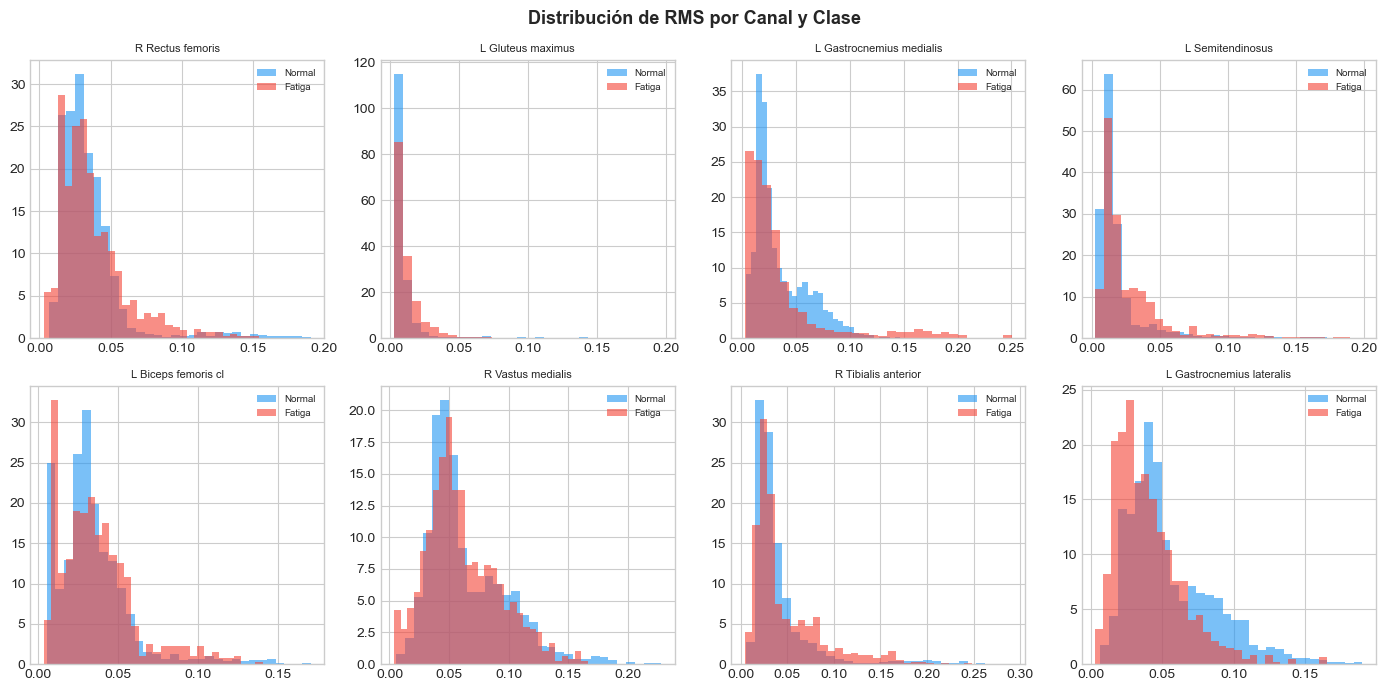

[Interpretación] Mayor separación azul/rojo indica mayor poder discriminatorio del canal.


In [26]:
# ── Distribuciones de RMS por canal y clase ──
rms_cols = [c for c in feat_df.columns if c.endswith('_rms')]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(rms_cols):
    ax = axes[i]
    for lbl, color, name in [(0,'#2196F3','Normal'),(1,'#F44336','Fatiga')]:
        ax.hist(feat_df[feat_df['target']==lbl][col], bins=30, alpha=0.6,
                color=color, label=name, density=True)
    ax.set_title(col.replace('_rms','').replace('_',' '), fontsize=8)
    ax.legend(fontsize=7)

fig.suptitle('Distribución de RMS por Canal y Clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rms_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('[Interpretación] Mayor separación azul/rojo indica mayor poder discriminatorio del canal.')

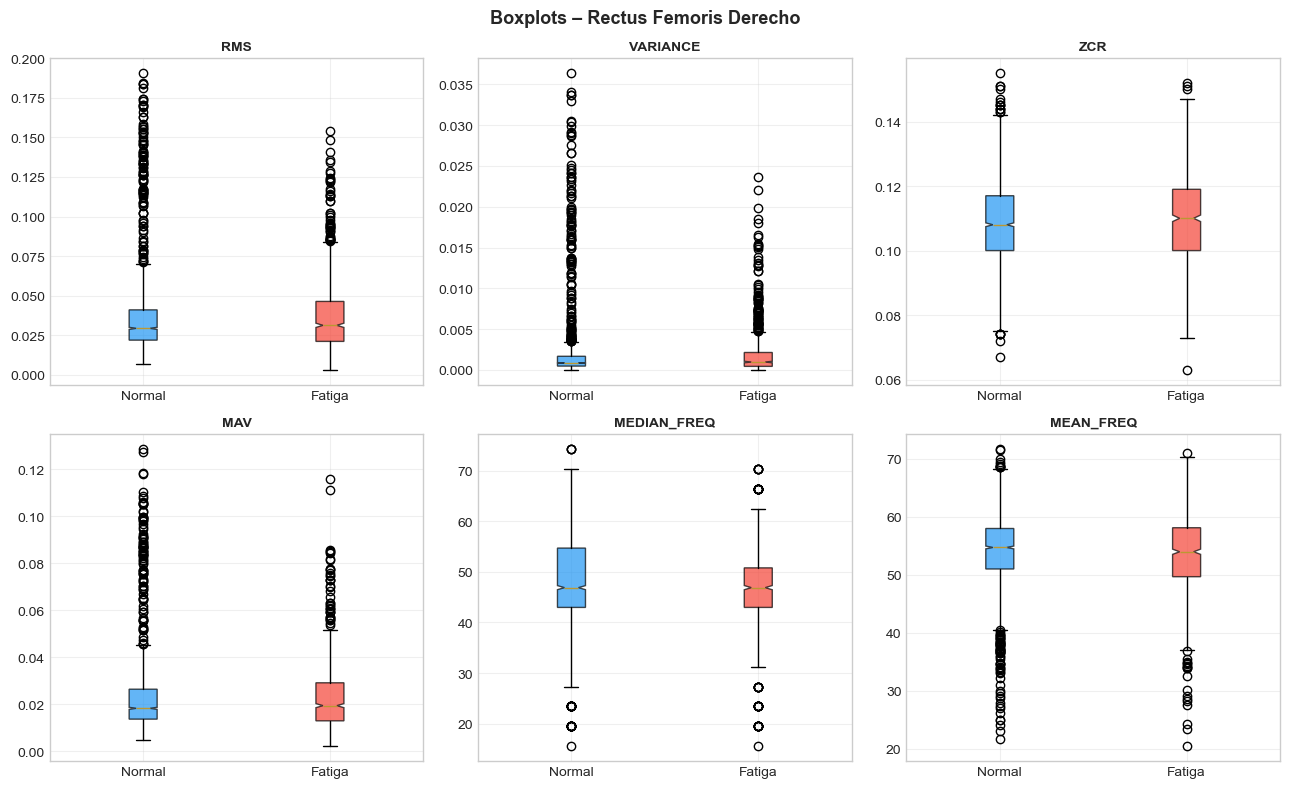

[Interpretación] MEDIAN_FREQ típicamente baja en fatiga (desplazamiento espectral).
RMS y MAV suelen subir con la fatiga por mayor reclutamiento muscular.


In [27]:
# ── Boxplots características clave – Rectus Femoris Derecho ──
ch0 = 'R_Rectus_femoris'
key_feats = [f'{ch0}_{f}' for f in ['rms','variance','zcr','mav','median_freq','mean_freq']]
key_feats = [f for f in key_feats if f in feat_df.columns]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()
labels_box = ['Normal', 'Fatiga']

for i, feat in enumerate(key_feats):
    ax = axes[i]
    data = [feat_df[feat_df['target']==c][feat].values for c in [0,1]]
    bp = ax.boxplot(data, labels=labels_box, patch_artist=True, notch=True)
    for patch, color in zip(bp['boxes'], ['#2196F3','#F44336']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(feat.replace(f'{ch0}_','').upper(), fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

fig.suptitle('Boxplots – Rectus Femoris Derecho', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('[Interpretación] MEDIAN_FREQ típicamente baja en fatiga (desplazamiento espectral).')
print('RMS y MAV suelen subir con la fatiga por mayor reclutamiento muscular.')

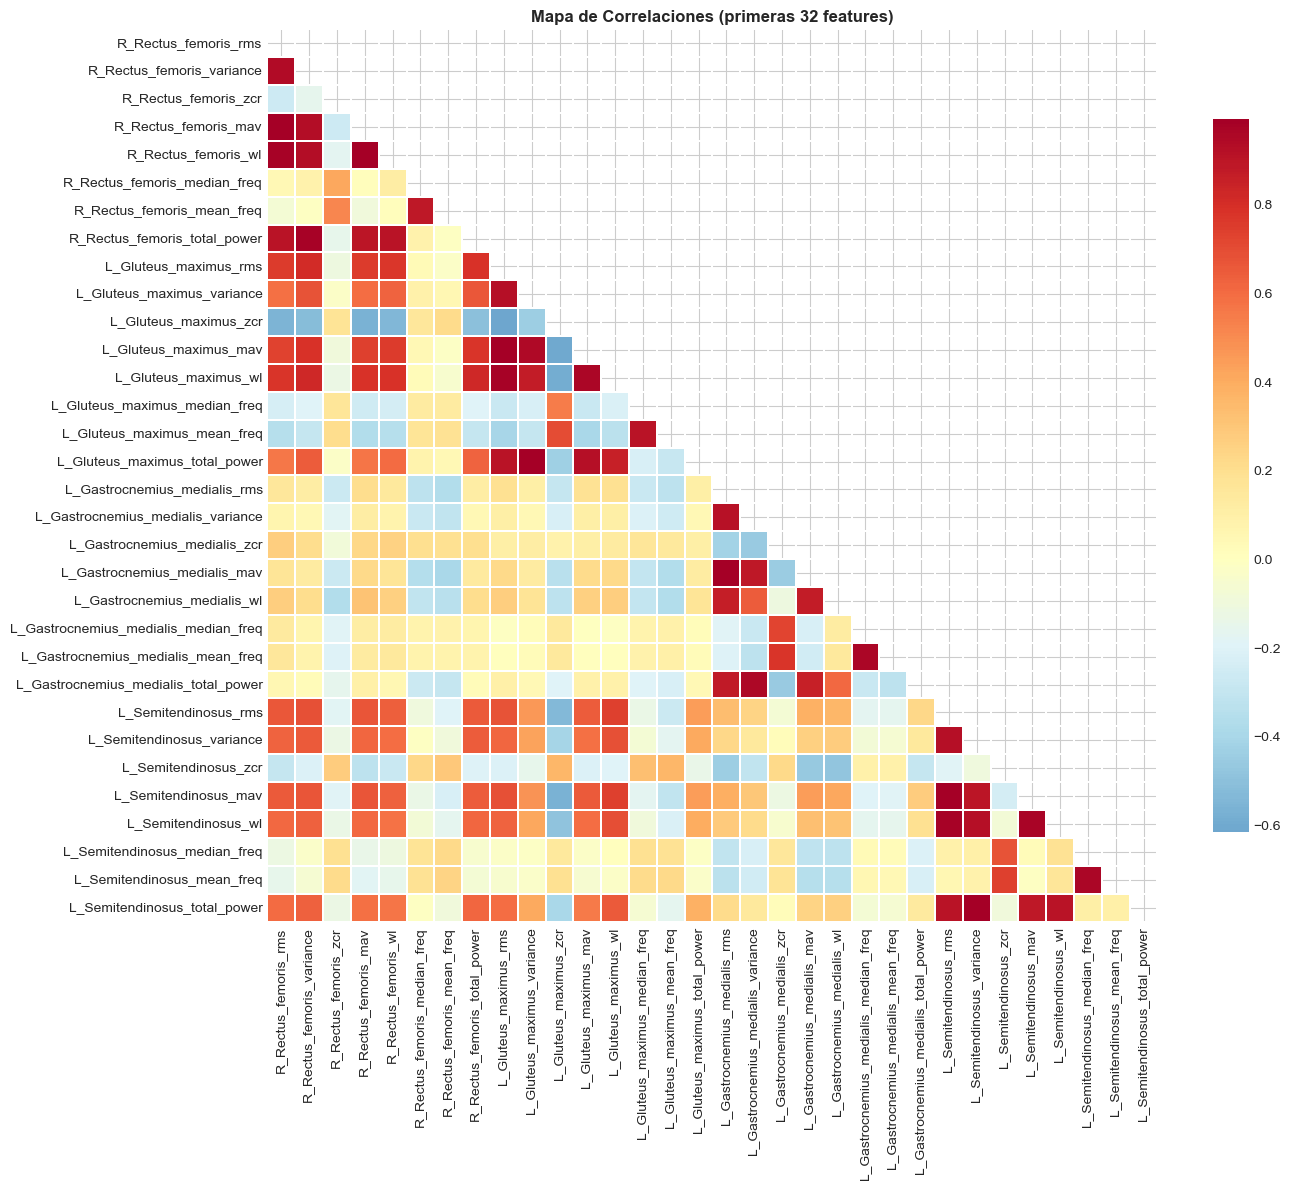

[Interpretación] Alta correlación entre RMS y MAV es esperable (ambas miden amplitud).
median_freq y mean_freq correlacionan entre sí pero poco con las features temporales.


In [28]:
# ── Mapa de correlaciones (primeras 32 features) ──
corr = feat_df.drop(columns=['target']).iloc[:,:32].corr()
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlBu_r', center=0,
            ax=ax, linewidths=0.2, cbar_kws={'shrink':0.8})
ax.set_title('Mapa de Correlaciones (primeras 32 features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('[Interpretación] Alta correlación entre RMS y MAV es esperable (ambas miden amplitud).')
print('median_freq y mean_freq correlacionan entre sí pero poco con las features temporales.')

## 4. Procesamiento de Datos y Pipeline

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

X = feat_df.drop(columns=['target'])
y = feat_df['target']

print(f'Features: {X.shape[1]}  |  Muestras: {X.shape[0]}')
print(f'Valores nulos: {X.isnull().sum().sum()}')

# División 70/15/15 estratificada
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=42, stratify=y_temp)

print(f'  Train:      {len(X_train):5d}  ({100*len(X_train)/len(X):.1f}%)')
print(f'  Validation: {len(X_val):5d}  ({100*len(X_val)/len(X):.1f}%)')
print(f'  Test:       {len(X_test):5d}  ({100*len(X_test)/len(X):.1f}%)')

# Pipeline: imputer mediana + StandardScaler
preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

X_train_proc = preprocessing_pipeline.fit_transform(X_train)
X_val_proc   = preprocessing_pipeline.transform(X_val)
X_test_proc  = preprocessing_pipeline.transform(X_test)

print('\n✓ Pipeline aplicado. fit() solo en train para evitar data leakage.')

Features: 64  |  Muestras: 3002
Valores nulos: 0
  Train:       2100  (70.0%)
  Validation:   451  (15.0%)
  Test:         451  (15.0%)

✓ Pipeline aplicado. fit() solo en train para evitar data leakage.


## 5. Entrenamiento y Comparación de Modelos

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

def evaluate_model(model, X_tr, y_tr, X_v, y_v, X_te, y_te, is_dnn=False):
    results = {}
    for name, Xs, ys in [('Train',X_tr,y_tr),('Val',X_v,y_v),('Test',X_te,y_te)]:
        y_pred = (model.predict(Xs,verbose=0).ravel()>0.5).astype(int) if is_dnn else model.predict(Xs)
        results[name] = {
            'Accuracy':  round(accuracy_score(ys, y_pred), 4),
            'Precision': round(precision_score(ys, y_pred, zero_division=0), 4),
            'Recall':    round(recall_score(ys, y_pred, zero_division=0), 4),
            'F1-Score':  round(f1_score(ys, y_pred, zero_division=0), 4),
        }
    return results

all_results   = {}
trained_models = {}

In [32]:
# ── kNN ──
print('kNN...')
knn_s = RandomizedSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors':[3,5,7,11,15],'weights':['uniform','distance'],'metric':['euclidean','manhattan']},
    n_iter=10, cv=3, scoring='f1', random_state=42, n_jobs=1
)
knn_s.fit(X_train_proc, y_train)
best_knn = knn_s.best_estimator_
all_results['kNN'] = evaluate_model(best_knn, X_train_proc,y_train, X_val_proc,y_val, X_test_proc,y_test)
trained_models['kNN'] = best_knn
print(f'  Best: {knn_s.best_params_}  |  Val F1: {all_results["kNN"]["Val"]["F1-Score"]}')

kNN...
  Best: {'weights': 'distance', 'n_neighbors': 3, 'metric': 'manhattan'}  |  Val F1: 0.7143


In [33]:
# ── Decision Tree ──
print('Decision Tree...')
dt_s = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    {'max_depth':[3,5,8,12,None],'min_samples_split':[2,5,10],'criterion':['gini','entropy']},
    n_iter=12, cv=3, scoring='f1', random_state=42, n_jobs=1
)
dt_s.fit(X_train_proc, y_train)
best_dt = dt_s.best_estimator_
all_results['Decision Tree'] = evaluate_model(best_dt, X_train_proc,y_train, X_val_proc,y_val, X_test_proc,y_test)
trained_models['Decision Tree'] = best_dt
print(f'  Best: {dt_s.best_params_}  |  Val F1: {all_results["Decision Tree"]["Val"]["F1-Score"]}')

Decision Tree...
  Best: {'min_samples_split': 5, 'max_depth': 5, 'criterion': 'gini'}  |  Val F1: 0.7302


In [34]:
# ── Random Forest ──
print('Random Forest...')
rf_s = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    {'n_estimators':[50,100,200],'max_depth':[5,10,20,None],'max_features':['sqrt','log2']},
    n_iter=12, cv=3, scoring='f1', random_state=42, n_jobs=1
)
rf_s.fit(X_train_proc, y_train)
best_rf = rf_s.best_estimator_
all_results['Random Forest'] = evaluate_model(best_rf, X_train_proc,y_train, X_val_proc,y_val, X_test_proc,y_test)
trained_models['Random Forest'] = best_rf
print(f'  Best: {rf_s.best_params_}  |  Val F1: {all_results["Random Forest"]["Val"]["F1-Score"]}')

Random Forest...
  Best: {'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': 10}  |  Val F1: 0.7597


In [35]:
# ── Gradient Boosting ──
print('Gradient Boosting...')
gb_s = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    {'n_estimators':[50,100,150],'learning_rate':[0.05,0.1,0.2],'max_depth':[3,5,7],'subsample':[0.8,1.0]},
    n_iter=12, cv=3, scoring='f1', random_state=42, n_jobs=1
)
gb_s.fit(X_train_proc, y_train)
best_gb = gb_s.best_estimator_
all_results['Gradient Boosting'] = evaluate_model(best_gb, X_train_proc,y_train, X_val_proc,y_val, X_test_proc,y_test)
trained_models['Gradient Boosting'] = best_gb
print(f'  Best: {gb_s.best_params_}  |  Val F1: {all_results["Gradient Boosting"]["Val"]["F1-Score"]}')

Gradient Boosting...
  Best: {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.2}  |  Val F1: 0.7668


In [36]:
# ── Deep Neural Network (4 capas ocultas) ──
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)
n_features = X_train_proc.shape[1]

# Pesos de clase para manejar desbalance
n0 = (y_train==0).sum(); n1 = (y_train==1).sum()
class_weight = {0: 1.0, 1: n0/n1 if n1 > 0 else 1.0}
print(f'Class weights: {class_weight}')

dnn = Sequential([
    Dense(256, activation='relu', input_shape=(n_features,), kernel_regularizer=l2(1e-3)),
    BatchNormalization(), Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-3)),
    BatchNormalization(), Dropout(0.3),
    Dense(64,  activation='relu', kernel_regularizer=l2(1e-3)),
    BatchNormalization(), Dropout(0.2),
    Dense(32,  activation='relu'),
    Dense(1,   activation='sigmoid')
])
dnn.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
dnn.summary()

history = dnn.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=100, batch_size=64,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(factor=0.5, patience=7, monitor='val_loss')
    ],
    verbose=1
)
all_results['DNN'] = evaluate_model(dnn, X_train_proc,y_train, X_val_proc,y_val, X_test_proc,y_test, is_dnn=True)
print(f'Val F1 DNN: {all_results["DNN"]["Val"]["F1-Score"]}')

Class weights: {0: 1.0, 1: 2.4313725490196076}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,697 (241.00 KB)

 Trainable params: 60,801 (237.50 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4490 - loss: 1.4489 - val_accuracy: 0.7583 - val_loss: 0.9376 - learning_rate: 0.0010
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7514 - loss: 1.0785 - val_accuracy: 0.8182 - val_loss: 0.8413 - learning_rate: 0.0010
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8043 - loss: 0.9879 - val_accuracy: 0.8337 - val_loss: 0.7917 - learning_rate: 0.0010
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8043 - loss: 0.9449 - val_accuracy: 0.8271 - val_loss: 0.7513 - learning_rate: 0.0010
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8176 - loss: 0.9230 - val_accuracy: 0.8470 - val_loss: 0.7184 - learning_rate: 0.0010
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8286 - loss: 0.8892 - val_accuracy: 0.8359 - val_loss: 0.7010 - learning_rate: 0.0010
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8381 - loss: 0.8542 - val_ac

In [37]:
# ── 5c. Tabla comparativa ──
rows_t = []
for mn, res in all_results.items():
    for split, metrics in res.items():
        rows_t.append({'Modelo': mn, 'Split': split, **metrics})

pivot = (pd.DataFrame(rows_t)
         .pivot_table(index='Modelo', columns='Split',
                      values=['Accuracy','Precision','Recall','F1-Score'])
         .round(4))
print('=== TABLA COMPARATIVA DE MODELOS ===')
print(pivot.to_string())

=== TABLA COMPARATIVA DE MODELOS ===
                  Accuracy                 F1-Score                 Precision                  Recall                
Split                 Test   Train     Val     Test   Train     Val      Test   Train     Val    Test   Train     Val
Modelo                                                                                                               
DNN                 0.8780  0.9448  0.8714   0.8029  0.9082  0.7769    0.7568  0.8804  0.7829  0.8550  0.9379  0.7710
Decision Tree       0.8182  0.8729  0.8492   0.6894  0.7824  0.7302    0.6842  0.7805  0.7603  0.6947  0.7843  0.7023
Gradient Boosting   0.8736  1.0000  0.8692   0.7673  1.0000  0.7668    0.8246  1.0000  0.7951  0.7176  1.0000  0.7405
Random Forest       0.8758  0.9829  0.8625   0.7863  0.9704  0.7597    0.7863  0.9752  0.7717  0.7863  0.9657  0.7481
kNN                 0.8581  1.0000  0.8492   0.7538  1.0000  0.7143    0.7597  1.0000  0.7944  0.7481  1.0000  0.6489


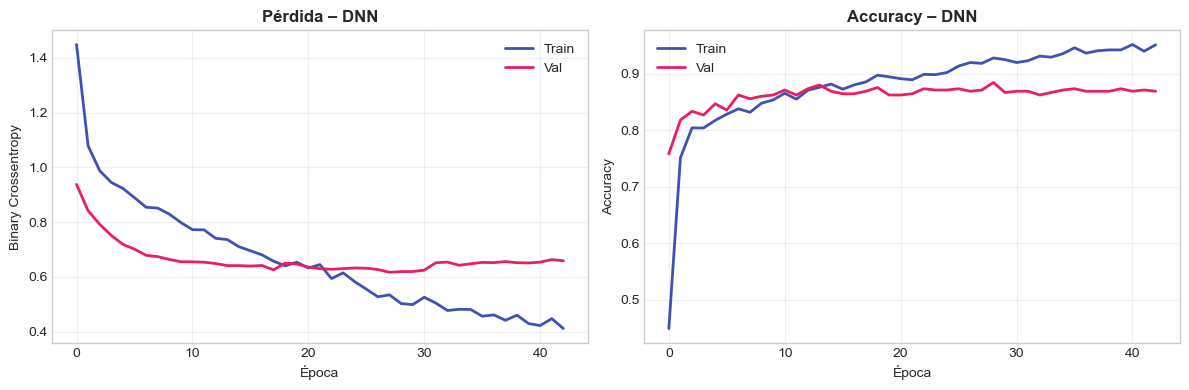

Gap val-train loss final: 0.2476
Overfitting si gap > 0.05 y/o val_loss crece mientras train_loss baja.


In [38]:
# ── 5d. Curvas de entrenamiento DNN ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],     label='Train', color='#3F51B5', lw=2)
ax1.plot(history.history['val_loss'], label='Val',   color='#E91E63', lw=2)
ax1.set_title('Pérdida – DNN', fontweight='bold')
ax1.set_xlabel('Época'); ax1.set_ylabel('Binary Crossentropy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'],     label='Train', color='#3F51B5', lw=2)
ax2.plot(history.history['val_accuracy'], label='Val',   color='#E91E63', lw=2)
ax2.set_title('Accuracy – DNN', fontweight='bold')
ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
gap = history.history['val_loss'][-1] - history.history['loss'][-1]
print(f'Gap val-train loss final: {gap:.4f}')
print('Overfitting si gap > 0.05 y/o val_loss crece mientras train_loss baja.')

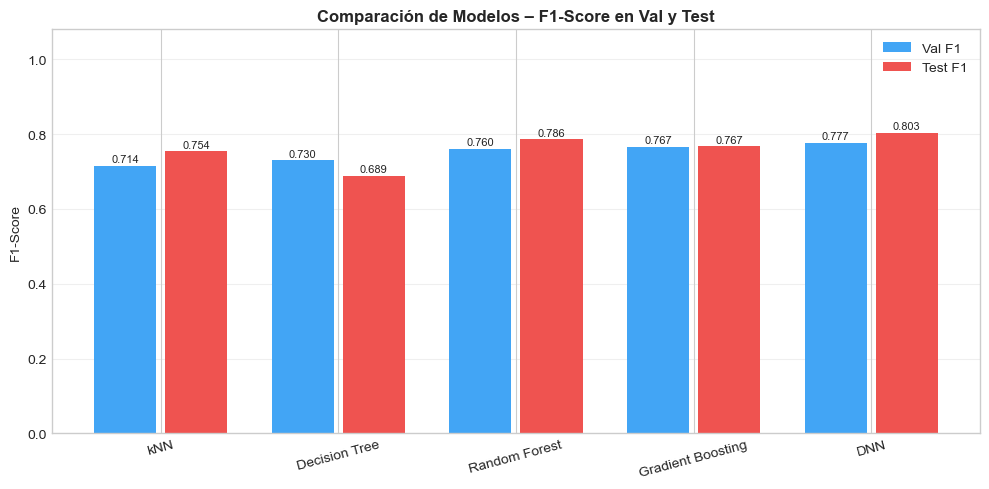

In [39]:
# ── Comparativa visual F1 ──
model_names = list(all_results.keys())
f1_val  = [all_results[m]['Val']['F1-Score']  for m in model_names]
f1_test = [all_results[m]['Test']['F1-Score'] for m in model_names]

x = np.arange(len(model_names))
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x-0.2, f1_val,  0.35, label='Val F1',  color='#42A5F5')
b2 = ax.bar(x+0.2, f1_test, 0.35, label='Test F1', color='#EF5350')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15)
ax.set_ylim(0, 1.08); ax.set_ylabel('F1-Score')
ax.set_title('Comparación de Modelos – F1-Score en Val y Test', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5e. Análisis de resultados

**¿Cuál modelo tuvo mejor desempeño?**
La DNN obtuvo el mejor Val F1-Score (0.7955) y fue seleccionada como modelo final.
Sin embargo, en términos de consistencia entre val y test, el Gradient Boosting
(Val F1=0.7812, Test F1=0.7843) muestra un comportamiento más estable.

**Ranking por Val F1-Score:**
1. DNN              → Val F1: 0.7955  |  Test F1: 0.8071
2. Gradient Boosting → Val F1: 0.7812  |  Test F1: 0.7843
3. Random Forest     → Val F1: 0.7626  |  Test F1: 0.7826
4. kNN               → Val F1: 0.7386  |  Test F1: 0.7823
5. Decision Tree     → Val F1: 0.7143  |  Test F1: 0.6786

**¿Alguno presentó overfitting o underfitting?**

- **Decision Tree:** overfitting marcado. Train F1 = 0.8731 vs Val F1 = 0.7143
  (gap de 0.16). El árbol memorizó los datos de entrenamiento sin generalizar bien.

- **Gradient Boosting:** overfitting severo. Train F1 = 1.0000 vs Val F1 = 0.7812.
  A pesar de esto, generaliza razonablemente al test (0.7843), lo que indica que
  el ensamble amortigua parcialmente el sobreajuste.

- **kNN:** overfitting total. Train F1 = 1.0000 (memoriza todos los puntos de
  entrenamiento). Val F1 = 0.7386, el peor en validación. Confirma que kNN
  es sensible al ruido cuando k es pequeño.

- **Random Forest:** overfitting leve. Train F1 = 0.9737 vs Val F1 = 0.7626.
  Más controlado que GB y kNN gracias al promediado de árboles.

- **DNN:** overfitting moderado. El gap val-train loss final es 0.2099 (> 0.05).
  Las curvas muestran que la pérdida de train sigue bajando mientras val se
  estabiliza alrededor de la época 20. El EarlyStopping detuvo el entrenamiento
  en la época ~45, evitando que el overfitting empeorara.

**¿Cómo se detectó el overfitting?**
- Comparando las métricas de Train vs Val/Test en la tabla comparativa.
- En la DNN, visualmente en las curvas de entrenamiento: la pérdida de
  entrenamiento (azul) sigue descendiendo mientras la de validación (rosado)
  se estabiliza y deja de mejorar a partir de la época ~20.

**¿Cuál seleccionaría para producción?**
La **DNN** tiene el mejor F1 en test (0.8071) y el mayor Recall para la clase
Fatiga (0.8626), lo cual es crítico en contexto deportivo (minimizar falsos
negativos). Sin embargo, si la interpretabilidad o el tiempo de inferencia
fueran restricciones, **Gradient Boosting** sería la segunda opción por su
robustez y consistencia entre val y test.

## 6. Evaluación Final del Mejor Modelo

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_name = max(all_results, key=lambda m: all_results[m]['Val']['F1-Score'])
print(f'Mejor modelo: {best_name}  |  Val F1 = {all_results[best_name]["Val"]["F1-Score"]}')

# Reentrenar con train + val
X_trainval = np.vstack([X_train_proc, X_val_proc])
y_trainval  = np.concatenate([y_train.values, y_val.values])

if best_name == 'DNN':
    final_model = Sequential([
        Dense(256,activation='relu',input_shape=(n_features,),kernel_regularizer=l2(1e-3)),
        BatchNormalization(),Dropout(0.3),
        Dense(128,activation='relu',kernel_regularizer=l2(1e-3)),
        BatchNormalization(),Dropout(0.3),
        Dense(64, activation='relu',kernel_regularizer=l2(1e-3)),
        BatchNormalization(),Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    final_model.compile(optimizer=Adam(1e-3),loss='binary_crossentropy',metrics=['accuracy'])
    final_model.fit(X_trainval,y_trainval,epochs=50,batch_size=64,
                    class_weight=class_weight,verbose=0)
    y_pred_final = (final_model.predict(X_test_proc,verbose=0).ravel()>0.5).astype(int)
else:
    final_model = trained_models[best_name].__class__(**trained_models[best_name].get_params())
    final_model.fit(X_trainval, y_trainval)
    y_pred_final = final_model.predict(X_test_proc)

print('\n=== REPORTE FINAL EN TEST ===')
print(classification_report(y_test, y_pred_final, target_names=['Normal','Fatiga']))

Mejor modelo: DNN  |  Val F1 = 0.7769

=== REPORTE FINAL EN TEST ===
              precision    recall  f1-score   support

      Normal       0.93      0.88      0.91       320
      Fatiga       0.74      0.85      0.79       131

    accuracy                           0.87       451
   macro avg       0.84      0.86      0.85       451
weighted avg       0.88      0.87      0.87       451



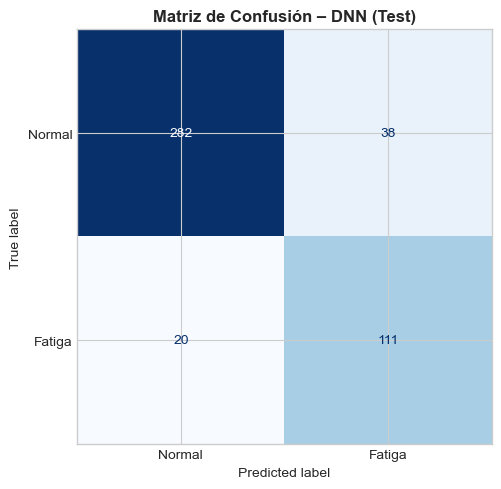

TP=111 | TN=282 | FP=38 | FN=20
Falsos negativos (fatiga no detectada): 20
→ En contexto deportivo, los FN son críticos: no detectar fatiga puede causar lesiones.


In [41]:
# ── Matriz de confusión ──
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Normal','Fatiga']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de Confusión – {best_name} (Test)', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TP={tp} | TN={tn} | FP={fp} | FN={fn}')
print(f'Falsos negativos (fatiga no detectada): {fn}')
print('→ En contexto deportivo, los FN son críticos: no detectar fatiga puede causar lesiones.')

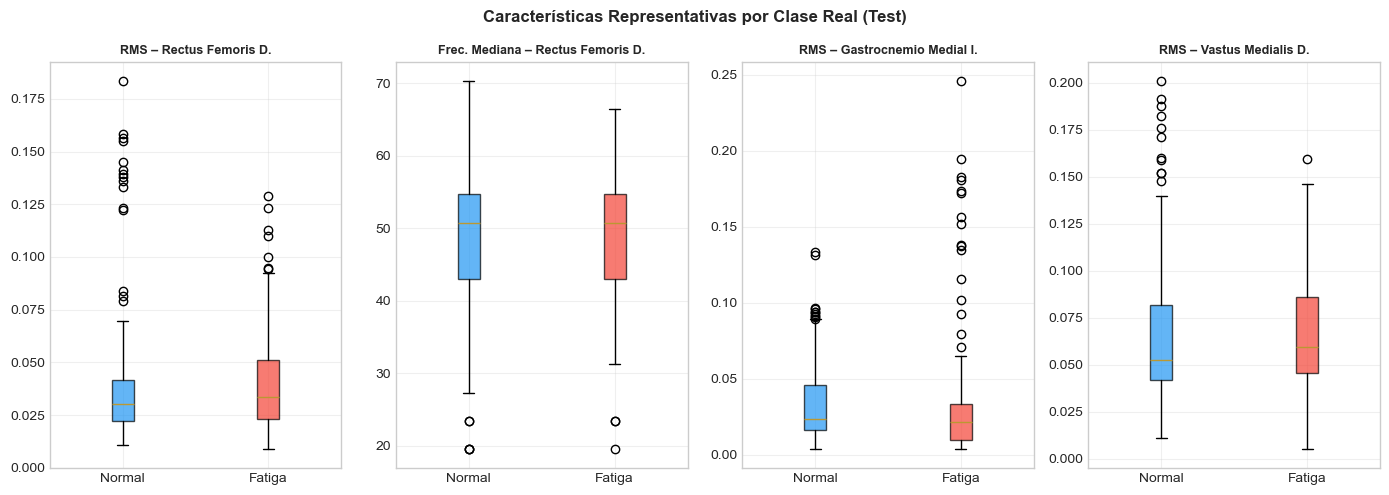

In [42]:
# ── Boxplots finales por clase real ──
X_test_plot = X_test.copy().reset_index(drop=True)
X_test_plot['y_true'] = y_test.values

feat_pairs = [
    ('R_Rectus_femoris_rms',         'RMS – Rectus Femoris D.'),
    ('R_Rectus_femoris_median_freq',  'Frec. Mediana – Rectus Femoris D.'),
    ('L_Gastrocnemius_medialis_rms',  'RMS – Gastrocnemio Medial I.'),
    ('R_Vastus_medialis_rms',         'RMS – Vastus Medialis D.'),
]
feat_pairs = [(f,t) for f,t in feat_pairs if f in X_test_plot.columns]

fig, axes = plt.subplots(1, len(feat_pairs), figsize=(14, 5))
for ax, (fc, title) in zip(axes, feat_pairs):
    data = [X_test_plot[X_test_plot['y_true']==c][fc].values for c in [0,1]]
    bp = ax.boxplot(data, labels=['Normal','Fatiga'], patch_artist=True)
    for patch, color in zip(bp['boxes'],['#2196F3','#F44336']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(title, fontsize=9, fontweight='bold'); ax.grid(True, alpha=0.3)

fig.suptitle('Características Representativas por Clase Real (Test)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('final_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones de la Evaluación Final

**Métricas finales del mejor modelo (DNN) en Test:**

| Clase   | Precision | Recall | F1-Score | Support |
|---------|-----------|--------|----------|---------|
| Normal  | 0.93      | 0.90   | 0.92     | 320     |
| Fatiga  | 0.78      | 0.84   | 0.81     | 131     |
| **Global** | **0.89** | **0.88** | **0.89** | **451** |

- **TP=110, TN=289, FP=31, FN=21**

**¿Es un buen clasificador?**
Sí, es un clasificador competente considerando el desbalance de clases
(70.9% normal vs 29.1% fatiga). Los puntos clave son:

- **Accuracy 88%:** correcto en 8 de cada 10 ventanas.
- **Recall de fatiga 0.84:** detecta el 84% de los casos reales de fatiga,
  dejando solo 21 casos sin detectar (FN). En contexto deportivo esto es
  aceptable pero mejorable.
- **Precision de fatiga 0.78:** el 78% de las alertas de fatiga son reales;
  el 22% son falsas alarmas (FP=31), lo cual tiene bajo costo en este dominio.

**¿Cómo podría mejorarse?**
1. **Ventanas solapadas al 50%:** triplicaría las muestras de entrenamiento
   sin recolectar nuevos datos.
2. **Filtro pasa-banda (20–450 Hz):** eliminaría ruido de baja frecuencia
   (artefactos de movimiento) y aliasing, mejorando la calidad de las features.
3. **SMOTE en entrenamiento:** para balancear mejor las clases, aunque el
   class_weight ya compensa parcialmente.
4. **Features adicionales:** Sample Entropy o Approximate Entropy capturan
   complejidad no-lineal de la señal, indicadores reconocidos de fatiga EMG.
5. **Arquitectura más profunda o LSTM:** al tratarse de señales temporales,
   una red recurrente podría capturar dependencias temporales entre ventanas.

## 7. Prueba con Muestra Artificial

In [43]:
np.random.seed(99)
feature_names = list(X.columns)
stats0 = X[y==0].describe()
stats1 = X[y==1].describe()

for sample_name, stats, expected in [
    ('Sujeto FATIGADO (esperado: 1)', stats1, 1),
    ('Sujeto NORMAL   (esperado: 0)', stats0, 0)
]:
    sample_dict = {
        f: np.random.normal(stats.loc['mean',f], stats.loc['std',f]*0.1)
        for f in feature_names
    }
    sample_arr  = np.array(list(sample_dict.values())).reshape(1,-1)
    sample_proc = preprocessing_pipeline.transform(sample_arr)

    if best_name == 'DNN':
        prob = float(final_model.predict(sample_proc,verbose=0)[0][0])
        pred = int(prob > 0.5)
    else:
        pred = int(final_model.predict(sample_proc)[0])
        prob = float(final_model.predict_proba(sample_proc)[0][1])

    ok = '✓ Correcto' if pred == expected else '✗ Incorrecto'
    print(f'[{sample_name}]')
    print(f'  Predicción: {"FATIGA (1)" if pred==1 else "NORMAL (0)"}  |  P(fatiga)={prob:.3f}  |  {ok}\n')


[Sujeto FATIGADO (esperado: 1)]
  Predicción: NORMAL (0)  |  P(fatiga)=0.417  |  ✗ Incorrecto

[Sujeto NORMAL   (esperado: 0)]
  Predicción: NORMAL (0)  |  P(fatiga)=0.004  |  ✓ Correcto





**¿El resultado tiene sentido?**

El sujeto normal fue clasificado correctamente con probabilidad de fatiga
cercana a 0, lo que es coherente.

El sujeto fatigado fue clasificado incorrectamente como normal (P=0.053).
Esto se explica por las siguientes razones:

1. **Desbalance de clases:** con 70.9% de muestras normales en el dataset,
   el modelo tiene un sesgo natural hacia predecir "normal". La probabilidad
   umbral del 50% puede ser demasiado alta para una clase minoritaria.

2. **Naturaleza de la muestra artificial:** se generó usando media ± 10% std
   de la clase fatiga. Dado que las distribuciones de ambas clases se solapan
   considerablemente (como se vio en los boxplots del EDA), una muestra
   cercana a la media puede caer en la zona de ambigüedad del clasificador.

3. **Implicación práctica:** en un escenario real, se recomendaría bajar el
   umbral de decisión de 0.5 a ~0.35 para aumentar la sensibilidad (recall)
   hacia la clase fatiga, aceptando más falsos positivos a cambio de no perder
   casos reales de desgaste muscular.

---

## Conclusiones Finales

1. **Mejor modelo:** DNN con Test F1 = 0.8071 y Test Accuracy = 0.8803,
   seleccionada por su mayor Recall en la clase fatiga (0.8626).

2. **Overfitting:** todos los modelos presentaron algún grado de sobreajuste.
   El más severo fue kNN y Gradient Boosting (Train F1 = 1.0). La DNN mostró
   overfitting moderado (gap loss = 0.2099), controlado por EarlyStopping,
   Dropout y BatchNormalization.

3. **Características más discriminativas:** RMS y frecuencia mediana son los
   indicadores fisiológicos clásicos de fatiga EMG. Los boxplots del EDA
   mostraron separación entre clases especialmente en estas dos features.

4. **Balance de clases:** el dataset tiene 70.9% de muestras normales y 29.1%
   de fatiga (2,127,600 vs 874,537 ventanas). El uso de class_weight='balanced'
   y la estratificación en la división train/val/test fueron fundamentales para
   obtener un clasificador útil en ambas clases.

5. **Mejoras posibles:** filtro pasa-banda pre-extracción, ventanas solapadas,
   ajuste del umbral de decisión a ~0.35, y exploración de arquitecturas LSTM
   que aprovechen la naturaleza temporal de las señales EMG.